# Task 2: Yelp polarity sentiment classification

No pretrained embeddings or language models: every `nn.Embedding` is randomly initialised. Baseline = bag of embeddings + MLP, Experimental 1 = multi-width CNN, Experimental 2 = BiLSTM with attention pooling. All models are scored by the shared `../eval_metrics.py`.

In [1]:
# Works on a local kernel (this Mac: CUDA > Apple MPS > CPU) and on a Colab GPU runtime.
MEMBER = "sivasurya_chandran"
TASK = "task2_sentiment"
DRIVE_REPO = "/content/drive/MyDrive/DATA266/lab1/repo"   # used only on Colab

import os, sys, json, glob
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir("/content/drive/MyDrive"):
        from google.colab import drive
        drive.mount("/content/drive")
    sys.path.insert(0, f"{DRIVE_REPO}/tools")
    import colab
    colab.setup(DRIVE_REPO, TASK, MEMBER)
else:
    if os.path.basename(os.getcwd()) == "src":   # VS Code starts the kernel next to the notebook
        os.chdir("..")
    sys.path.insert(0, os.path.abspath("../../tools"))
    import colab   # only launch()/monitor() are used locally
    import torch
    dev = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print("working in", os.path.relpath(os.getcwd(), os.path.abspath("../..")), "| torch", torch.__version__, "| device:", dev)

working in task2_sentiment/sivasurya_chandran | torch 2.8.0 | device: mps


## 1. EDA and preprocessing: length/class distribution, malformed entries, lowercasing, punctuation and stopword removal (negations kept), Porter stemming, tokenisation, own vocabulary

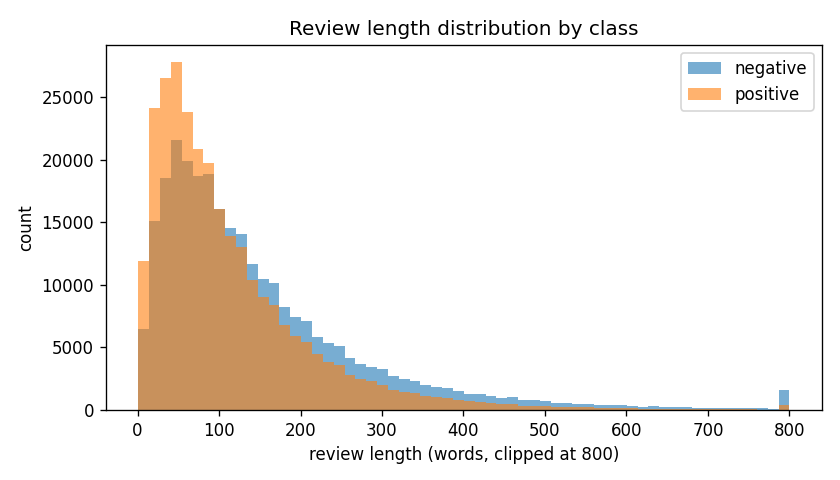

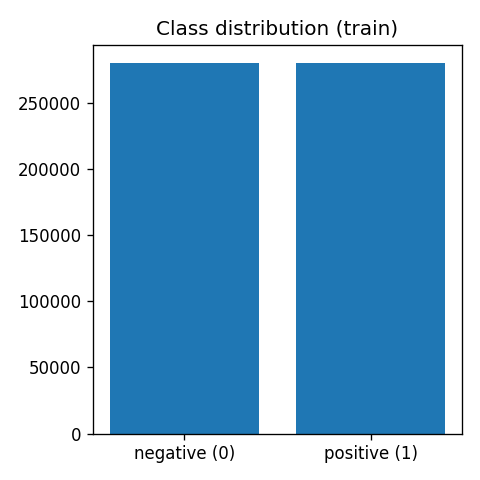

{
  "eda": {
    "n_train": 560000,
    "class_counts": {
      "0": 280000,
      "1": 280000
    },
    "class_balance_ratio_min_over_max": 1.0,
    "length_words_mean": 133.0288732142857,
    "length_words_median": 97.0,
    "length_words_p95": 372.0,
    "length_words_max": 1052,
    "length_by_class_mean": {
      "0": 151.5271857142857,
      "1": 114.53056071428571
    }
  },
  "removed_malformed_train": 24,
  "exact_duplicates_train": 0,
  "removed_malformed_test": 0,
  "exact_duplicates_test": 0,
  "vocab_size": 50000,
  "raw_unique_tokens": 143116,
  "token_len_mean_after_cleaning": 72.24642891866526,
  "pct_truncated_at_max_seq_len": 2.3288668773897325,
  "unk_rate_test": 0.004083937354743022,
  "splits": {
    "train": 503979,
    "val": 55997,
    "test": 38000
  },
  "example_cleaning": {
    "raw": "Contrary to other reviews, I have zero complaints about the service or the prices. I have been getting tire service here for the past 5 years now, and compared to my experien

In [2]:
if not os.path.exists("data_processed/X_train.npy"):
    !python src/preprocess.py --config config.yaml
from IPython.display import Image, display
display(Image("data_processed/eda/review_length_distribution.png"), Image("data_processed/eda/class_distribution.png"))
print(json.dumps(json.load(open("data_processed/preprocess_stats.json")), indent=2)[:3000])

## 2. Train baseline + 2 experimental models; full metrics, bootstrap CIs, McNemar

In [3]:
# Starts training in the background on the runtime (adds --resume automatically if checkpoints/train_state.pt exists).
colab.launch("python src/train.py --config config.yaml", done_file="checkpoints/metrics_task2.json", resumable=False)

already finished (checkpoints/metrics_task2.json exists), nothing to do


In [4]:
# Live tail of the unedited raw log. Interrupting this cell does NOT stop training; re-run it to keep watching.
colab.monitor(done_file="checkpoints/metrics_task2.json")

finished: checkpoints/metrics_task2.json


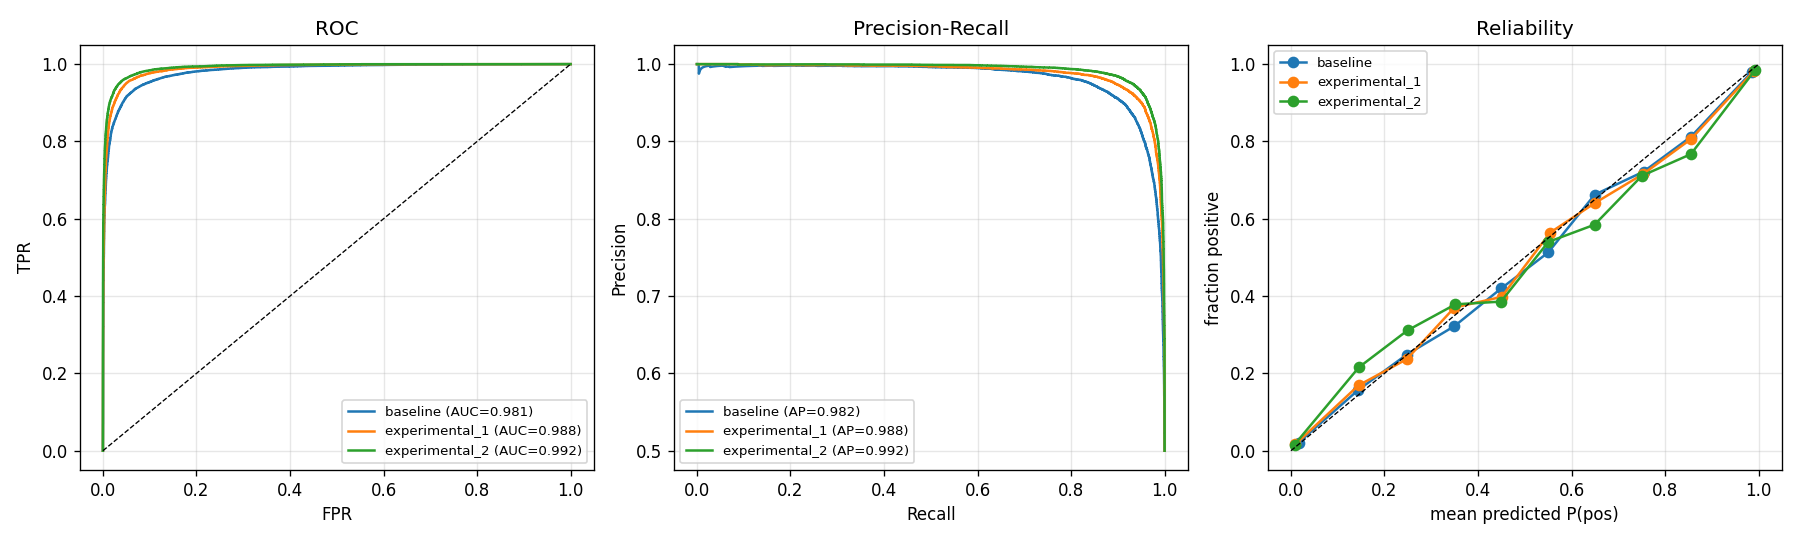

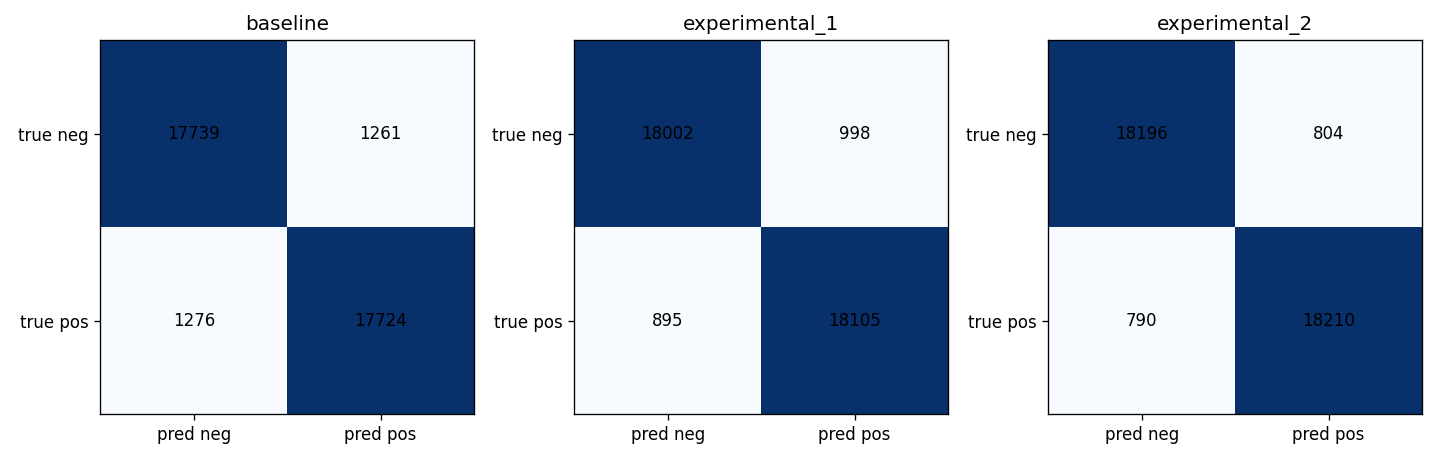

baseline        bag     acc=0.9332 macroF1=0.9332 AUC=0.9812 MCC=0.8665 ECE=0.0082 params=6,416,770 hw=Apple Silicon (MPS)
experimental_1  cnn     acc=0.9502 macroF1=0.9502 AUC=0.9883 MCC=0.9004 ECE=0.0105 params=6,597,762 hw=Apple Silicon (MPS)
experimental_2  bilstm  acc=0.9581 macroF1=0.9581 AUC=0.9921 MCC=0.9161 ECE=0.0124 params=6,697,730 hw=Apple Silicon (MPS)
{
  "baseline_vs_experimental_1": {
    "b_A_right_B_wrong": 688,
    "c_A_wrong_B_right": 1332,
    "statistic": 204.67772277227724,
    "p_value": 0.0,
    "method": "chi2_cc"
  },
  "baseline_vs_experimental_2": {
    "b_A_right_B_wrong": 542,
    "c_A_wrong_B_right": 1485,
    "statistic": 437.77207696102613,
    "p_value": 0.0,
    "method": "chi2_cc"
  }
}


In [5]:
display(Image("checkpoints/test_curves.png"), Image("checkpoints/test_confusion.png"))
m = json.load(open("checkpoints/metrics_task2.json"))
for n, r in m["models"].items():
    print(f"{n:15s} {r['type']:7s} acc={r['accuracy']:.4f} macroF1={r['f1_macro']:.4f} AUC={r['roc_auc']:.4f} MCC={r['mcc']:.4f} ECE={r['ece']:.4f} params={r['param_count']:,} hw={r['hardware'].get('gpu', r['hardware']['cpu'])}")
print(json.dumps(m["mcnemar"], indent=2))

## 3. Manual error review: 20 errors (5 confident FP, 5 confident FN, 5 near-threshold, 5 worst-slice)

In [6]:
if not os.path.exists("checkpoints/error_review_experimental_2.md"):
    !python src/error_analysis.py --config config.yaml --model_name experimental_2
print(open("checkpoints/error_review_experimental_2.md").read()[:6000])

# Error review — experimental_2

Worst slice: `contains_but_contrast` (error rate 0.047)

### confident_false_positive — test #29330
- true: **negative**, predicted: **positive** (P(pos)=0.9999)
- suggested error type: sarcasm / irony
- final error type: _
- proposed testable fix: _

> Wow love the place and everything is very clean and new!  Great place to come and relax worth a try!  Cheers,  Eric Van Nguyen Visited April 2012

### confident_false_positive — test #15988
- true: **negative**, predicted: **positive** (P(pos)=0.9997)
- suggested error type: mixed sentiment / contrast clause
- final error type: _
- proposed testable fix: _

> Local dining icons deserve their own criteria for recognition.  That said, adding sliced tomato, coleslaw and a pile of fries to a deli sandwich defines the Primanti as a Pittsburgh-area institution.  Their cheesesteaks will never threaten the best of Philly's, nor will their pastrami or corned beef be mistaken for New York deli; this only serves to

## 4. Metric tables and deliverables

In [7]:
!cd ../.. && python tools/export_reports.py --member {MEMBER}
!cd ../.. && python tools/make_tables.py --member {MEMBER}
if IN_COLAB:
    colab.sync_back(DRIVE_REPO, TASK, MEMBER)

wrote task1_llm/sivasurya_chandran/metrics_report.csv
kept existing task1_llm/sivasurya_chandran/failure_analysis.md
wrote task2_sentiment/sivasurya_chandran/metrics_report.csv
wrote task2_sentiment/sivasurya_chandran/failure_analysis.md
task3: no metrics yet


# Metric tables — sivasurya_chandran (from `checkpoints/`)


## Task 1

| Metric | Value |
|---|---|
| Training cross-entropy (nats/char) | 0.6303 |
| Validation cross-entropy (nats/char) | 0.6385 |
| Perplexity (val) | 1.8937 |
| Bits-per-character (val) | 0.9212 |
| Generalization gap (val − train) | 0.0082 |
| Top-1 next-char accuracy (val) | 0.7955 |
| Distinct-1 / 2 / 3 | 0.2525 / 0.6764 / 0.8860 |
| Repeated 4-gram rate (sampled / greedy) | 0.0063 / 0.2671 |
| Grad norm mean / p95 / max | 0.343 / 0.489 / 7.770 |
| NaN steps / loss spikes | 0 / 0 |
| fp16 overflow steps skipped by GradScaler | 41 |
| Parameter count | 4,827,648 |
| Training tokens/sec | 133,346 |
| Generation tokens/sec | 217.1832 |
| Peak memory (MB) | 943.9868 |
| Total training time (s) | 6,735.6416 |

## Task 2

| Metric | baseline (bag) | experimental_1 (cnn) | experimental_2 (bilstm) |
|---|---|---|---|
| Accuracy | 0.9332 | 0.9502 | 0.9581 |
| Precision macro | 0.9332 | 0.9502 | 0.9581 |
| Recall macro | 0.